# Integrated Project 2

Fernando Soares Goudard

The activity consists of working for a fictional startup that sells food products. You need to analyze user behavior for the company's app.

First, study the sales funnel. Find out how users reach the purchase stage. How many users actually reach this stage? How many get stuck in the previous stages? Which stages in particular?

Next, look at the results of the A/A/B test. The designers would like to change the fonts throughout the app, but the managers fear that users will find the new design intimidating. They decide to make the decision based on the results of an A/A/B test.

Users are divided into three groups: two control groups receive the old fonts and one test group receives the new ones. Find out which set of fonts produces the best results.
Data description

Each log entry is a user action or event.

    EventName — event name
    DeviceIDHash — unique user identifier
    EventTimestamp — event time
    ExpId — experiment number

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

### Part 1: Importing the data

In [2]:
df = pd.read_csv('logs_exp_us.csv', sep='\t')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


Let's start by checking if we can transform the EventName column from string to another lighter type.
We can see that we don't have any null entries in the dataset.

In [3]:
df['EventName'].describe()

count               244126
unique                   5
top       MainScreenAppear
freq                119205
Name: EventName, dtype: object

In [4]:
df['EventName'] = df['EventName'].astype('category')

df.columns = df.columns.str.lower()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   eventname       244126 non-null  category
 1   deviceidhash    244126 non-null  int64   
 2   eventtimestamp  244126 non-null  int64   
 3   expid           244126 non-null  int64   
dtypes: category(1), int64(3)
memory usage: 5.8 MB


Let's check for duplicates

In [6]:
print('Number of duplicate lines:', df.duplicated().sum())

Number of duplicate lines: 413


Since the number of duplicates is much smaller than the total (>1%), we will discard these lines.

In [7]:
df = df[~df.duplicated()]
df.reset_index(drop=True, inplace=True)
df.info()
print(df.sample(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243713 entries, 0 to 243712
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   eventname       243713 non-null  category
 1   deviceidhash    243713 non-null  int64   
 2   eventtimestamp  243713 non-null  int64   
 3   expid           243713 non-null  int64   
dtypes: category(1), int64(3)
memory usage: 5.8 MB
                      eventname         deviceidhash  eventtimestamp  expid
188325         MainScreenAppear  7757211127624459946      1565085307    247
74706          MainScreenAppear  1675308806875779310      1564796724    246
13535          MainScreenAppear  6406754032190502504      1564653998    248
74979          CartScreenAppear  1754140665440434215      1564798966    247
46865          MainScreenAppear  8652597388469225782      1564732941    247
35240          MainScreenAppear  6572690767876555543      1564686539    247
115251         MainScreen

Now let's transform the timestamp column into two columns, one with date and time and the other with date only.

In [8]:
df['eventdatetime'] = pd.to_datetime(df['eventtimestamp'], unit='s')
df['eventdate'] = df['eventdatetime'].dt.date
print(df.head())

                 eventname         deviceidhash  eventtimestamp  expid  \
0         MainScreenAppear  4575588528974610257      1564029816    246   
1         MainScreenAppear  7416695313311560658      1564053102    246   
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248   
3         CartScreenAppear  3518123091307005509      1564054127    248   
4  PaymentScreenSuccessful  6217807653094995999      1564055322    248   

        eventdatetime   eventdate  
0 2019-07-25 04:43:36  2019-07-25  
1 2019-07-25 11:11:42  2019-07-25  
2 2019-07-25 11:28:47  2019-07-25  
3 2019-07-25 11:28:47  2019-07-25  
4 2019-07-25 11:48:42  2019-07-25  


### Part 2: Initial Data Analysis

In [9]:
events = df['eventtimestamp'].count()
users = df['deviceidhash'].nunique()
print(events, 'events in log')
print(users, 'users in log')

df_users = df.groupby('deviceidhash').agg({'eventname':'count'})
events_per_users = df_users['eventname'].mean()
print(f'Average of {events_per_users:.2f} events per user')

min_date = df['eventdate'].min()
max_date = df['eventdate'].max()
print(f'Events range from {min_date} to {max_date}')

243713 events in log
7551 users in log
Average of 32.28 events per user
Events range from 2019-07-25 to 2019-08-07


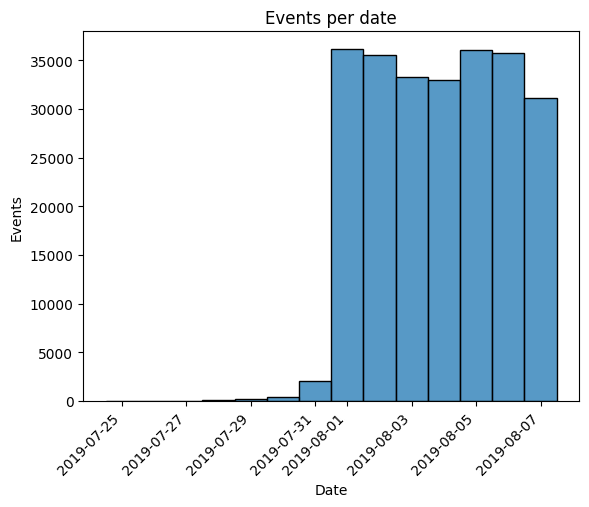

In [10]:
fig = sns.histplot(df['eventdate'])
fig.set_title('Events per date')
fig.set_ylabel('Events')
fig.set_xlabel('Date')
plt.xticks(rotation=45, ha='right')
plt.show()

According to the histogram, there are few events prior to August 1, 2019.
Therefore, our data corresponds to the period from August 1 to August 7, 2019, and data prior to this period should be discarded so as not to impact the analysis.

In [11]:
df_f = df[df['eventdate'] >= pd.to_datetime('2019-08-01').date()].reset_index(drop=True)
df_f.info()
print()
min_date = df_f['eventdate'].min()
max_date = df_f['eventdate'].max()
print(f'Events now range from {min_date} to {max_date}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240887 entries, 0 to 240886
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   eventname       240887 non-null  category      
 1   deviceidhash    240887 non-null  int64         
 2   eventtimestamp  240887 non-null  int64         
 3   expid           240887 non-null  int64         
 4   eventdatetime   240887 non-null  datetime64[ns]
 5   eventdate       240887 non-null  object        
dtypes: category(1), datetime64[ns](1), int64(3), object(1)
memory usage: 9.4+ MB

Events now range from 2019-08-01 to 2019-08-07


In [12]:
events_lost = df.shape[0]-df_f.shape[0]
events_lost_percent = events_lost*100/df.shape[0]

df_groups = df_f.groupby('expid', as_index=False).agg({'deviceidhash':'nunique'})
df_groups.columns = ['group','users']
df_groups_tot = df_groups['users'].sum()
df_groups['%'] = 100*df_groups['users']/df_groups_tot

print(f'We have lost {events_lost} events, representing {events_lost_percent:.2f}% of total events')
print()
print('Number of users per experiment group:')
display(df_groups)

We have lost 2826 events, representing 1.16% of total events

Number of users per experiment group:


,group,users,%
0,246,2484,32.970534
1,247,2513,33.355455
2,248,2537,33.674011


### Part 3 - Event Funnel Study:

In [13]:
df_events = df_f.groupby('eventname', observed=True, as_index=False).agg({'eventtimestamp':'count','deviceidhash':'nunique'})
df_events.columns = ['event','count','unique_users']
df_events = df_events.sort_values(by='count', ascending=False).reset_index(drop=True)

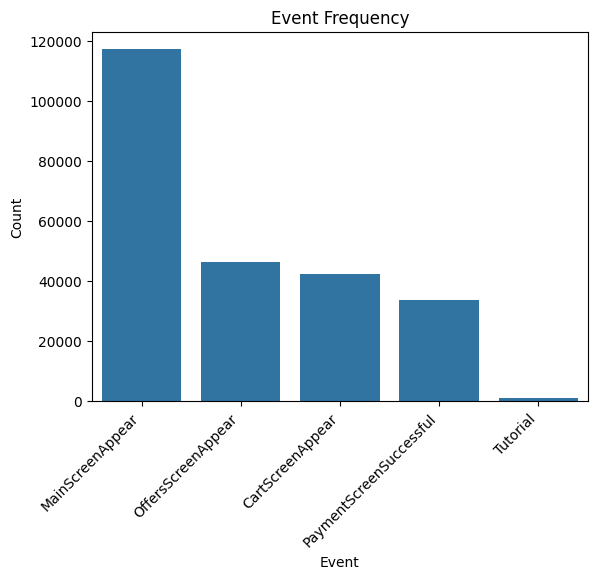

,event,count
0,MainScreenAppear,117328
1,OffersScreenAppear,46333
2,CartScreenAppear,42303
3,PaymentScreenSuccessful,33918
4,Tutorial,1005


In [14]:
fig = sns.barplot(data=df_events, x='event', y='count', order = df_events['event'])
plt.xticks(rotation=45, ha='right')
fig.set_title('Event Frequency')
fig.set_xlabel('Event')
fig.set_ylabel('Count')
plt.show()
display(df_events[['event','count']])

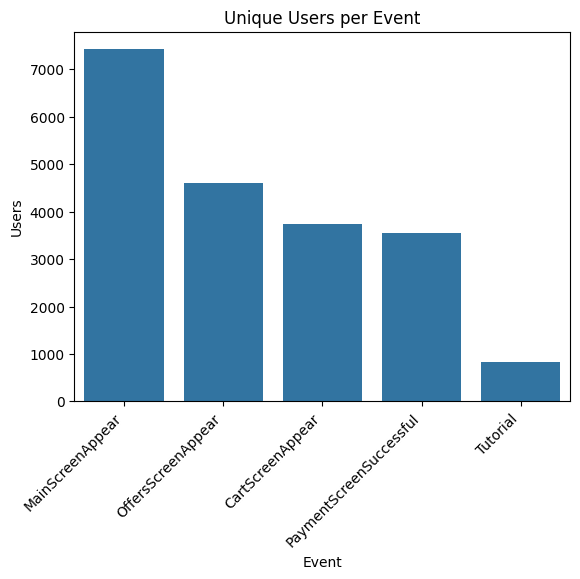

,event,unique_users
0,MainScreenAppear,7419
1,OffersScreenAppear,4593
2,CartScreenAppear,3734
3,PaymentScreenSuccessful,3539
4,Tutorial,840


In [15]:
df_events = df_events.sort_values(by='unique_users', ascending=False).reset_index(drop=True)

fig = sns.barplot(data=df_events, x='event', y='unique_users', order = df_events['event'])
plt.xticks(rotation=45, ha='right')
fig.set_title('Unique Users per Event')
fig.set_xlabel('Event')
fig.set_ylabel('Users')
plt.show()
display(df_events[['event','unique_users']])

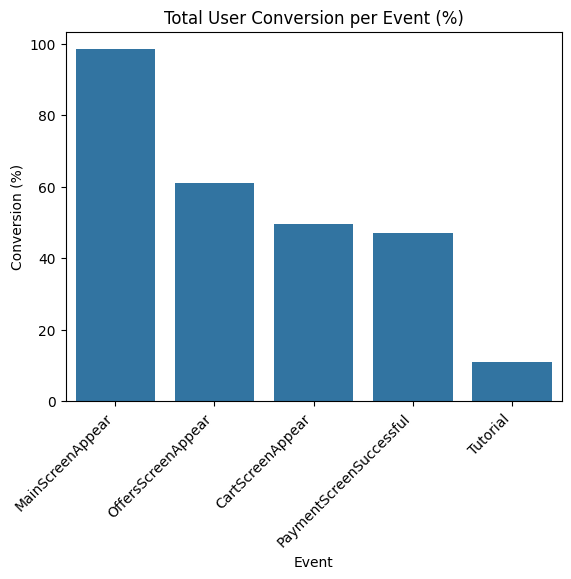

,event,total_conversion
0,MainScreenAppear,98.473586
1,OffersScreenAppear,60.963632
2,CartScreenAppear,49.561986
3,PaymentScreenSuccessful,46.973719
4,Tutorial,11.149456


In [16]:
tot_users = df_f['deviceidhash'].nunique()
df_events['total_conversion'] = 100*df_events['unique_users']/tot_users

fig = sns.barplot(data=df_events, x='event', y='total_conversion', order = df_events['event'])
plt.xticks(rotation=45, ha='right')
fig.set_title('Total User Conversion per Event (%)')
fig.set_xlabel('Event')
fig.set_ylabel('Conversion (%)')
plt.show()
display(df_events[['event','total_conversion']])

In my opinion, the Tutorial is not part of the funnel, and is an optional step.

When entering the application, the customer follows this path:

    > Accesses the main screen
    > Accesses the offers screen
    > Accesses the cart screen
    > Makes the payment

The Tutorial is an optional step that should appear the first time the person opens the application.

Since only 11% of customers accessed the tutorial, the other 89% should skip this step.

Since 98% of customers accessed the home screen, perhaps the other 2% gave up on the app during the tutorial.

Let's check if this order of events is correct:

In [17]:
funnel = df_f.pivot_table(index = 'deviceidhash', columns = 'eventname', values = 'eventdatetime', aggfunc='min', observed=False)
display(funnel.head())

eventname,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,Tutorial
deviceidhash,,,,,
6888746892508752,NaT,2019-08-06 14:06:34,NaT,NaT,NaT
6909561520679493,2019-08-06 18:52:58,2019-08-06 18:52:54,2019-08-06 18:53:04,2019-08-06 18:52:58,NaT
6922444491712477,2019-08-04 14:19:40,2019-08-04 14:19:33,2019-08-04 14:19:46,2019-08-04 14:19:40,NaT
7435777799948366,NaT,2019-08-05 08:06:34,NaT,NaT,NaT
7702139951469979,2019-08-02 14:28:45,2019-08-01 04:29:54,2019-08-01 04:29:56,2019-08-02 14:28:45,NaT


In [18]:
display(funnel.query('MainScreenAppear.notna()').head())
display(funnel.query('OffersScreenAppear.isna()').head())

eventname,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,Tutorial
deviceidhash,,,,,
6888746892508752,NaT,2019-08-06 14:06:34,NaT,NaT,NaT
6909561520679493,2019-08-06 18:52:58,2019-08-06 18:52:54,2019-08-06 18:53:04,2019-08-06 18:52:58,NaT
6922444491712477,2019-08-04 14:19:40,2019-08-04 14:19:33,2019-08-04 14:19:46,2019-08-04 14:19:40,NaT
7435777799948366,NaT,2019-08-05 08:06:34,NaT,NaT,NaT
7702139951469979,2019-08-02 14:28:45,2019-08-01 04:29:54,2019-08-01 04:29:56,2019-08-02 14:28:45,NaT


eventname,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,Tutorial
deviceidhash,,,,,
6888746892508752,NaT,2019-08-06 14:06:34,NaT,NaT,NaT
7435777799948366,NaT,2019-08-05 08:06:34,NaT,NaT,NaT
20449203507642281,NaT,2019-08-06 21:04:21,NaT,NaT,NaT
24144092107925848,NaT,2019-08-01 12:53:16,NaT,NaT,NaT
26317307137967461,NaT,2019-08-01 14:33:57,NaT,NaT,NaT


We can see that the ‘MainScreenAppear’ event appears to be the first in the sequence, as we suspected.

In [19]:
display(funnel.query('CartScreenAppear.isna()').head())

eventname,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,Tutorial
deviceidhash,,,,,
6888746892508752,NaT,2019-08-06 14:06:34,NaT,NaT,NaT
7435777799948366,NaT,2019-08-05 08:06:34,NaT,NaT,NaT
8740973466195562,NaT,2019-08-02 09:16:48,2019-08-02 09:43:59,NaT,NaT
12692216027168046,NaT,2019-08-02 16:28:49,2019-08-05 04:06:02,NaT,NaT
20449203507642281,NaT,2019-08-06 21:04:21,NaT,NaT,NaT


OffersScreenAppear is the second event

In [20]:
display(funnel.query('PaymentScreenSuccessful.isna()').head())

eventname,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,Tutorial
deviceidhash,,,,,
6888746892508752,NaT,2019-08-06 14:06:34,NaT,NaT,NaT
7435777799948366,NaT,2019-08-05 08:06:34,NaT,NaT,NaT
8486814028069281,2019-08-05 04:49:18,2019-08-05 04:52:40,2019-08-05 04:49:13,NaT,NaT
8740973466195562,NaT,2019-08-02 09:16:48,2019-08-02 09:43:59,NaT,NaT
12692216027168046,NaT,2019-08-02 16:28:49,2019-08-05 04:06:02,NaT,NaT


CartScreenAppear the third

In [21]:
display(funnel.query('PaymentScreenSuccessful.notna()').head())

eventname,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,Tutorial
deviceidhash,,,,,
6909561520679493,2019-08-06 18:52:58,2019-08-06 18:52:54,2019-08-06 18:53:04,2019-08-06 18:52:58,NaT
6922444491712477,2019-08-04 14:19:40,2019-08-04 14:19:33,2019-08-04 14:19:46,2019-08-04 14:19:40,NaT
7702139951469979,2019-08-02 14:28:45,2019-08-01 04:29:54,2019-08-01 04:29:56,2019-08-02 14:28:45,NaT
9841258664663090,2019-08-03 10:52:15,2019-08-03 10:47:59,2019-08-03 10:49:42,2019-08-03 17:57:27,2019-08-03 10:47:28
15708180189885246,2019-08-01 11:06:19,2019-08-01 16:08:23,2019-08-01 05:38:55,2019-08-01 11:06:19,NaT


And PamentScreenSuccessful is the last one to appear.

In [22]:
display(funnel.query('Tutorial.notna()').head())

eventname,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,Tutorial
deviceidhash,,,,,
9841258664663090,2019-08-03 10:52:15,2019-08-03 10:47:59,2019-08-03 10:49:42,2019-08-03 17:57:27,2019-08-03 10:47:28
29094035245869447,2019-08-02 13:15:22,2019-08-02 13:13:24,2019-08-02 13:13:43,2019-08-02 15:23:05,2019-08-02 13:13:20
41866159597273689,NaT,2019-08-03 13:31:36,2019-08-04 14:56:47,NaT,2019-08-03 13:31:03
51078901260117593,NaT,2019-08-04 05:22:29,NaT,NaT,2019-08-04 05:34:44
65731010663501604,NaT,2019-08-03 11:07:32,NaT,NaT,2019-08-03 11:07:34


We can see that the Tutorial event can happen before or after the MainScreenAppear event.

This leaves us with a few possible funnels:

    MainScreenAppear -> OffersScreenAppear -> CartScreenAppear -> PaymentScreenSuccessful
    Tutorial -> MainScreenAppear -> OffersScreenAppear -> CartScreenAppear -> PaymentScreenSuccessful
    MainScreenAppear -> Tutorial -> OffersScreenAppear -> CartScreenAppear -> PaymentScreenSuccessful

The first is the most common because the Tutorial has the lowest number of visits per user.

Now let's create the event funnel to check what percentage of users moved from one stage to the next.

In [23]:
step_1 = funnel['MainScreenAppear'].notna()
step_2 = step_1 & (funnel['OffersScreenAppear'] > funnel['MainScreenAppear'])
step_3 = step_2 & (funnel['CartScreenAppear'] > funnel['OffersScreenAppear'])
step_4 = step_3 & (funnel['PaymentScreenSuccessful'] > funnel['CartScreenAppear'])

MainScreenAppear_1 = funnel[step_1].shape[0]
OffersScreenAppear_1 = funnel[step_2].shape[0]
CartScreenAppear_1 = funnel[step_3].shape[0]
PaymentScreenSuccessful_1 = funnel[step_4].shape[0]

list_event_1 = [MainScreenAppear_1,OffersScreenAppear_1 ,CartScreenAppear_1 , PaymentScreenSuccessful_1] 

name_event_1 = ['MainScreenAppear','OffersScreenAppear' ,'CartScreenAppear' , 'PaymentScreenSuccessful'] 


In [24]:
def funnel_chart (labels, values, title):
    with plt.style.context("fivethirtyeight"):
        fig = plt.figure(figsize=(12,10))

        plt.fill_betweenx(y=[9,11], x1=[16,16], x2=[2,2], color="dodgerblue");

        plt.fill_betweenx(y=[8,9], x1=[14,16], x2=[4,2], color="dodgerblue", alpha=0.5);
        plt.fill_betweenx(y=[6,8], x1=[14,14], x2=[4,4], color="dodgerblue");

        plt.fill_betweenx(y=[5,6], x1=[12,14], x2=[6,4], color="dodgerblue", alpha=0.5);
        plt.fill_betweenx(y=[3,5], x1=[12,12], x2=[6,6], color="dodgerblue");

        plt.fill_betweenx(y=[2,3], x1=[10,12], x2=[8,6], color="dodgerblue", alpha=0.5);
        plt.fill_betweenx(y=[0,2], x1=[10,10], x2=[8,8], color="dodgerblue");

        plt.yticks([1,4,7,10], labels[::-1]);
        plt.xticks([],[]);

        plt.ylabel("Stage");

        for y, val in zip([1,4,7,10,13],values[::-1]):
            plt.text(9,y,val, ha="center", fontsize=16, fontweight="bold", color="white")

        plt.grid(visible=False);
        plt.title(title, loc="center", fontsize=25, fontweight="bold");

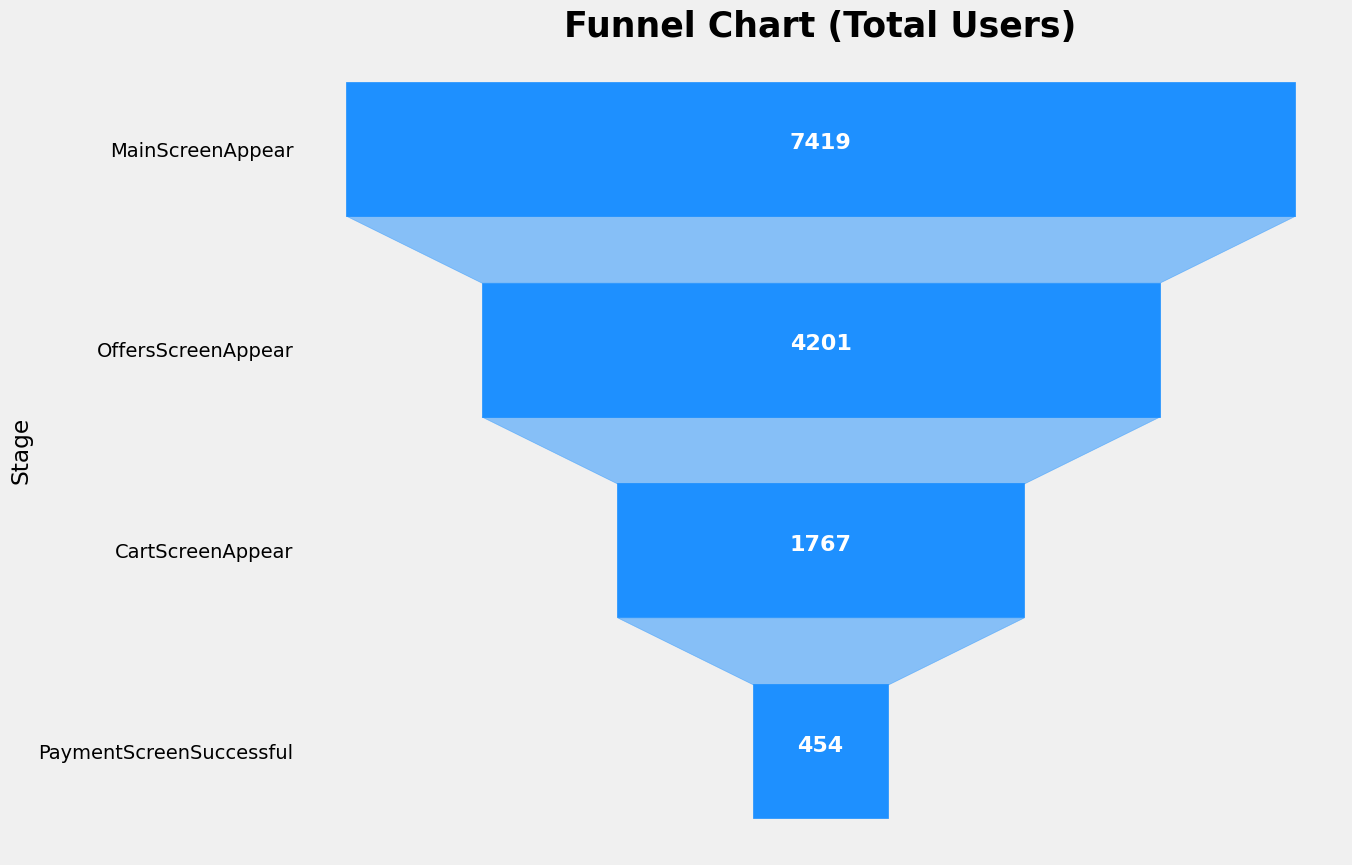

In [25]:
funnel_chart(name_event_1, list_event_1, "Funnel Chart (Total Users)")

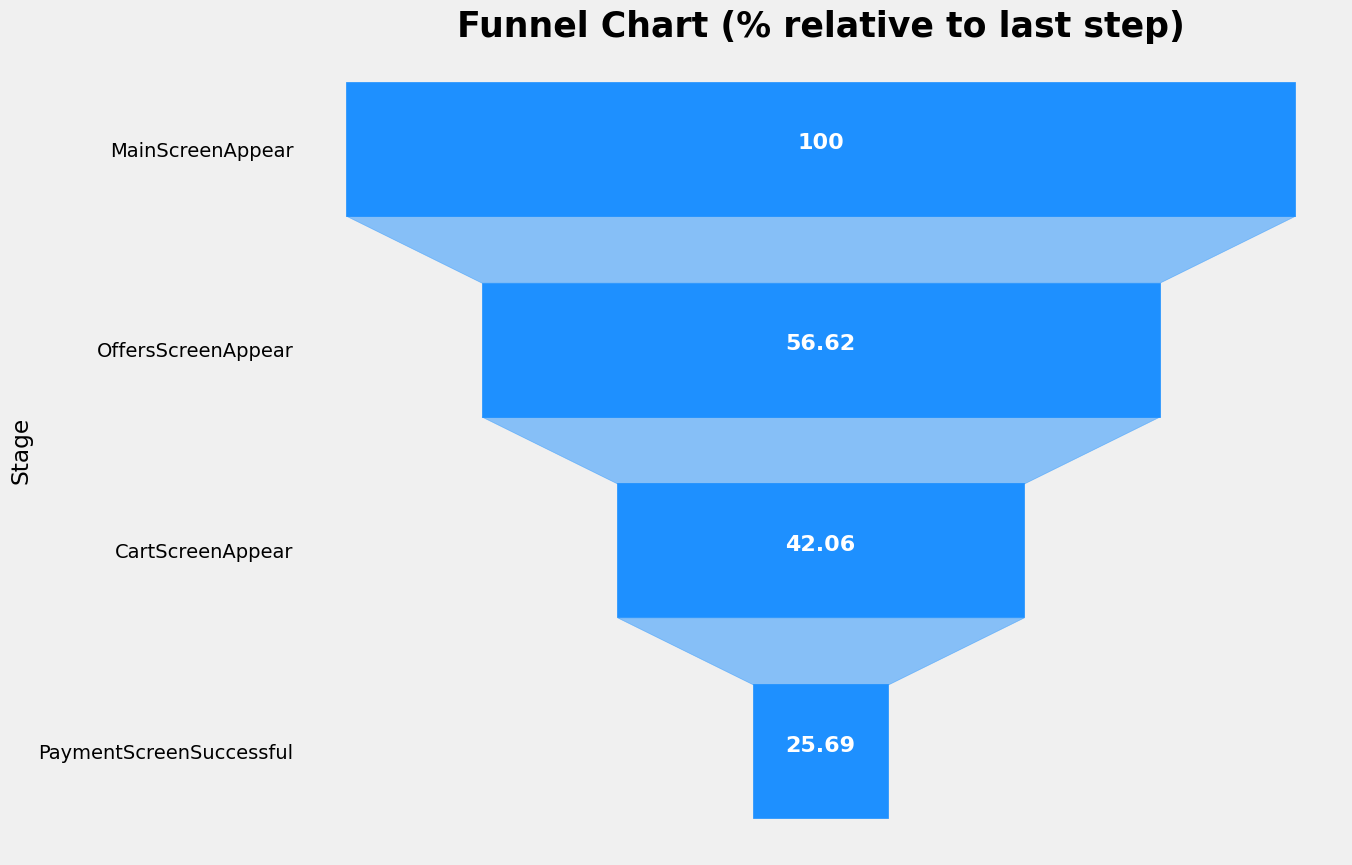

In [26]:
list_rel_perc = [100]
for i in range(1, 4):
    list_rel_perc.append(round(100*list_event_1[i]/list_event_1[i-1], 2))

funnel_chart(name_event_1, list_rel_perc, "Funnel Chart (% relative to last step)")

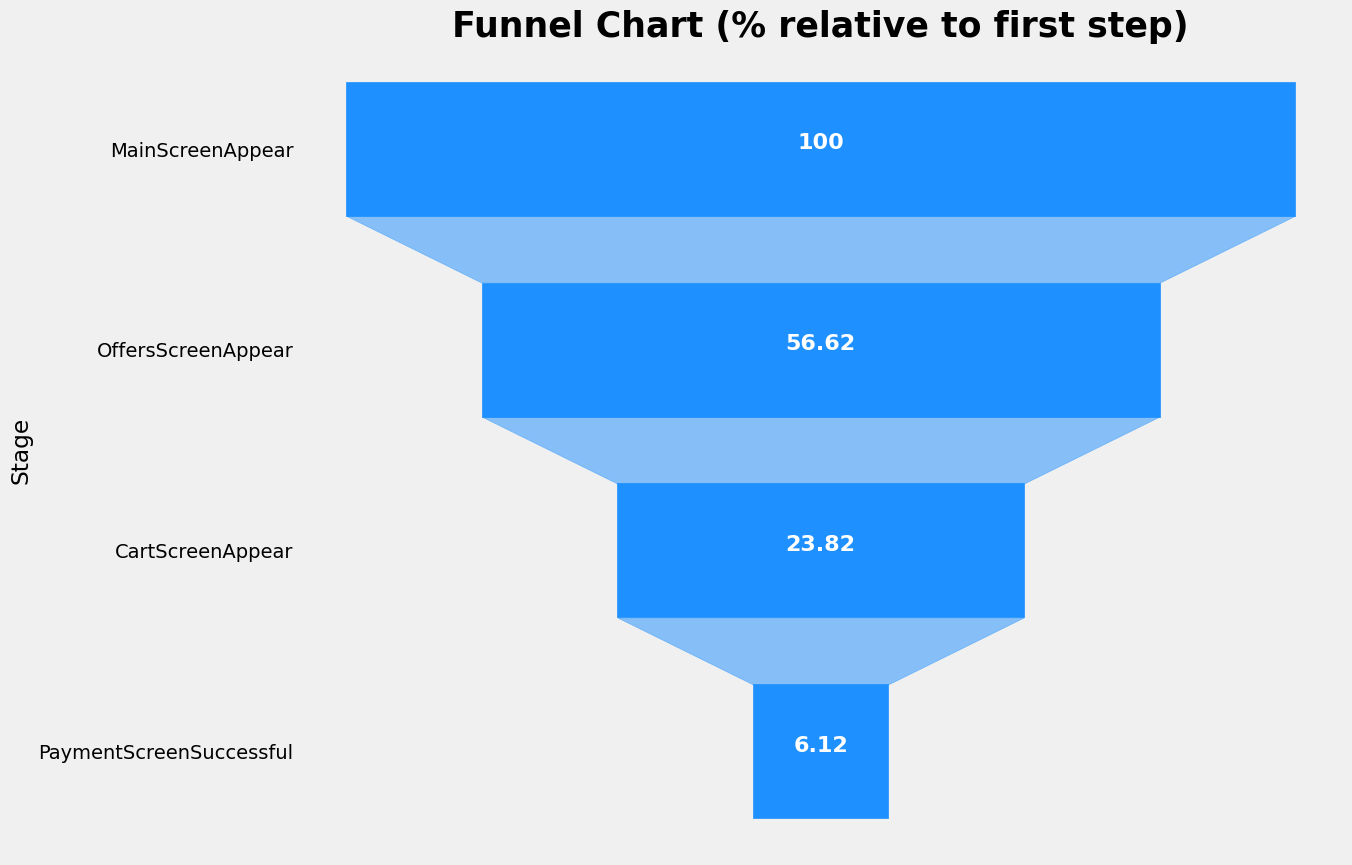

In [27]:
list_tot_perc = [100]
for i in range(1, 4):
    list_tot_perc.append(round(100*list_event_1[i]/list_event_1[0], 2))

funnel_chart(name_event_1, list_tot_perc, "Funnel Chart (% relative to first step)")

### Part 4 - Studying the results of the experiment:

In [28]:
print('Number of users per experiment group:')
display(df_groups)

Number of users per experiment group:


,group,users,%
0,246,2484,32.970534
1,247,2513,33.355455
2,248,2537,33.674011


We can see that the groups are well divided, with less than 1% variation between groups.

Let's confirm that we don't have any users who participated in more than one group.

In [29]:
dup_users = df_f.groupby('deviceidhash', as_index=False).agg({'expid':'nunique'})
dup_users_list = dup_users['deviceidhash'].duplicated()

print(f'We have {dup_users_list.sum()} users in more than one group')

display(dup_users[dup_users_list])

We have 0 users in more than one group


,deviceidhash,expid


Let's continue with the A/A tests (246/247) to confirm that our division of groups is being carried out correctly and will not interfere with our statistical tests.

We will perform Z-tests with an alpha of 0.05. For the A/A tests, the hypotheses are:

H0: The events have an equal conversion rate;
H1: The events have a different conversion rate.

In [30]:
# we will first create a function for the A/B tests

def ab_test(value, test_aa=False):
    alpha=0.05
    pivot = df_f.pivot_table(index=['deviceidhash','expid'], values=value, aggfunc='max').reset_index()

    test = pivot.groupby('expid', observed=False, as_index=False).agg({value:['sum','count']})
    test.columns=['expid','success','observ']

    if test_aa:
        success=test['success'].to_list()[0:2]
        observ=test['observ'].to_list()[0:2]
    else:
        success=[test.loc[0:1,'success'].sum(), test.loc[2,'success']]
        observ=[test.loc[0:1,'observ'].sum(), test.loc[2,'observ']]

    # Z test:
    z, p = proportions_ztest(success, observ)

    display(f'z-statistic: {z}')
    display(f'p-value: {p}')

    if p < alpha:
        display("Null hypothesis rejected: the samples are statistically different")
    else:
        display("Failure to reject the null hypothesis: the samples are NOT statistically different") 


In [31]:
df_f.info()
print(df_f['eventname'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240887 entries, 0 to 240886
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   eventname       240887 non-null  category      
 1   deviceidhash    240887 non-null  int64         
 2   eventtimestamp  240887 non-null  int64         
 3   expid           240887 non-null  int64         
 4   eventdatetime   240887 non-null  datetime64[ns]
 5   eventdate       240887 non-null  object        
dtypes: category(1), datetime64[ns](1), int64(3), object(1)
memory usage: 9.4+ MB
['Tutorial', 'MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']
Categories (5, object): ['CartScreenAppear', 'MainScreenAppear', 'OffersScreenAppear', 'PaymentScreenSuccessful', 'Tutorial']


In [32]:
# now we will create some columns to allow our ab tests

df_f['main'] = np.where(df_f['eventname'] == 'MainScreenAppear', 1, 0)
df_f['offers'] = np.where(df_f['eventname'] == 'OffersScreenAppear', 1, 0)
df_f['cart'] = np.where(df_f['eventname'] == 'CartScreenAppear', 1, 0)
df_f['payment'] = np.where(df_f['eventname'] == 'PaymentScreenSuccessful', 1, 0)
df_f['tutorial'] = np.where(df_f['eventname'] == 'Tutorial', 1, 0)

display(df_f.head())

,eventname,deviceidhash,eventtimestamp,expid,eventdatetime,eventdate,main,offers,cart,payment,tutorial
0,Tutorial,3737462046622621720,1564618048,246,2019-08-01 00:07:28,2019-08-01,0,0,0,0,1
1,MainScreenAppear,3737462046622621720,1564618080,246,2019-08-01 00:08:00,2019-08-01,1,0,0,0,0
2,MainScreenAppear,3737462046622621720,1564618135,246,2019-08-01 00:08:55,2019-08-01,1,0,0,0,0
3,OffersScreenAppear,3737462046622621720,1564618138,246,2019-08-01 00:08:58,2019-08-01,0,1,0,0,0
4,MainScreenAppear,1433840883824088890,1564618139,247,2019-08-01 00:08:59,2019-08-01,1,0,0,0,0


In [33]:
#Lets conduct our A/A tests:

event_list = ['main','offers','cart','payment','tutorial']
event_label = {'main':'MainScreenAppear',
               'offers':'OffersScreenAppear',
               'cart':'CartScreenAppear',
               'payment':'PaymentScreenSuccessful',
               'tutorial':'Tutorial'}

for event in event_list:
    display(f'A/A Test for: {event_label[event]}')
    ab_test(event, True)
    print()

'A/A Test for: MainScreenAppear'

'z-statistic: 0.3093441851418436'

'p-value: 0.7570597232046099'

'Failure to reject the null hypothesis: the samples are NOT statistically different'

'A/A Test for: OffersScreenAppear'

...

'Failure to reject the null hypothesis: the samples are NOT statistically different'

'A/A Test for: Tutorial'

'z-statistic: -0.0781614596617372'

'p-value: 0.9376996189257114'

'Failure to reject the null hypothesis: the samples are NOT statistically different'

We were unable to reject the null hypothesis in any A/A test, so we can say that the two samples are statistically equal.

Let's now perform the A/B tests.

In [34]:
for event in event_list:
    display(f'A/B Test for: {event_label[event]}')
    ab_test(event, False)
    print()

'A/B Test for: MainScreenAppear'

'z-statistic: 1.048854111361149'

'p-value: 0.29424526837179577'

'Failure to reject the null hypothesis: the samples are NOT statistically different'

'A/B Test for: OffersScreenAppear'

...

'Failure to reject the null hypothesis: the samples are NOT statistically different'

'A/B Test for: Tutorial'

'z-statistic: 0.2991016694401563'

'p-value: 0.764862472531507'

'Failure to reject the null hypothesis: the samples are NOT statistically different'

Based on the results of the A/B tests, we can conclude that there is no significant difference between the groups with the new and old fonts, meaning that the change in fonts did not significantly alter user behavior.

### Conclusion:

The average user of the app performs the following sequence:

    > Accesses the main screen
    > Accesses the offers screen
    > Accesses the cart screen
    > Makes the payment.

A/B testing revealed that changing the font did not alter user behavior. This change did not alter the conversion rate or frequency of any funnel events.